# Drone Obstacle Avoidance with TurboMPC

This tutorial shows how to set up and solve a constrained MPC problem using the **SQP-ADMM** solver in TurboMPC. We use a 2D planar drone navigating around circular obstacles as the running example.

The optimal control problem (OCP) solved at each time step is:

\begin{align*}
\min_{(x_{0:T},\, u_{0:T-1})}  \ &\sum_{t=0}^{T-1} \bigl( x_t^\top Q x_t + u_t^\top R u_t + r_d \|u_t - u_{t-1}\|^2 \bigr) + x_T^\top Q_T x_T
\\
\text{s.t.} \quad \ \  &x_{t+1} = f(x_t, u_t), \quad \|u_t\|_\infty \le u_{\max}, \quad h_i(x_t) \ge 0 \;\; \forall\, i
\end{align*}
where:
- $x_t \in \mathbb{R}^6$: drone state $(p_x, p_y, p_z, v_x, v_y, v_z)$ at time $t$
- $u_t \in \mathbb{R}^3$: control input at time $t$
- $Q, Q_T \succeq 0$ — state stage and terminal cost matrices
- $R \succ 0$: control cost matrix
- $r_d \ge 0$: control-rate weight penalising $\|u_t - u_{t-1}\|^2$ (encourages smooth inputs)
- $f(x_t, u_t)$: nonlinear drone dynamics integrated with RK4 by default
- $h_i(x_t) = \|p_t - c_i\| - r_i$:  signed distance to obstacle $i$ (center $c_i \in \mathbb{R}^2$, radius $r_i > 0$).

**Slack-variable relaxation.** When obstacle constraints cannot be satisfied, the hard inequalities are replaced by a soft version:

\begin{align*}
\min_{(x,u,\xi)}\quad \; &\cdots + \gamma_\xi \sum_{t,i} \|\xi_t^i\|^2
\\
\text{s.t.} \quad\ \ \,  &\cdots, \quad h_i(x_t) + \xi_t \ge 0 \;\; \forall\, i,\, \forall t
\end{align*}

where $\gamma_\xi > 0$ is the slack penalty weight.

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

from jax import config

config.update("jax_enable_x64", True)  # use double precision

import jax

from turbompc.solvers.turbompc_solver import (
    BACKWARD_BACKEND_CHOICES,
    FORWARD_BACKEND_CHOICES,
    TurboMPCSolver,
    parse_backward_backend,
    parse_forward_backend,
)
from examples.drone_utils import (
    collect_turbompc_drone_trajectory,
    make_drone_config,
    DRONE_X0_BASE,
    OBS_CENTERS,
    OBS_RADII,
)

# Available solver backends
print("Forward backends:")
for b in FORWARD_BACKEND_CHOICES:
    print(f"  {b}")

print("\nBackward backends:")
for b in BACKWARD_BACKEND_CHOICES:
    print(f"  {b}")

print(f"\nJAX devices: {jax.devices()}")


Forward backends:
  admm_fused_cudss
  admm_fused_pcg
  admm_jax_loop_cudss_ffi
  admm_jax_loop_jax_dense
  admm_jax_loop_pcg
  admm_jax_loop_pcg_ffi

Backward backends:
  admm_fused_cudss
  admm_fused_pcg
  admm_jax_loop_cudss_ffi
  admm_jax_loop_jax_dense
  admm_jax_loop_pcg
  admm_jax_loop_pcg_ffi
  direct_cudss_ffi
  direct_jax_dense

JAX devices: [CudaDevice(id=0)]


### Problem and solver parameters

In [3]:
# Simulation
seeds = [0, 1]              # seeds for initial-state randomisation
sim_steps = 50              # closed-loop simulation steps

# OCP dimensions
horizon = 50                # MPC prediction horizon
dt = 1.0                    # discretisation time step (s)

# Discretization discretization_scheme: 0 = Euler, 2 = RK4, 10 = implicit trapezoidal
discretization_scheme = 2

# Cost weights
rd_weight = 0.01            # control-rate weight r_d
slack_weight = 10.0         # slack penalty λ (only used in the slack case)

# TurboMPC solver knobs
sqp_iter = 8                # max SQP (outer) iterations per MPC step
admm_max_iter = 50          # max ADMM (inner) iterations per SQP step
admm_tol = 1e-3             # ADMM convergence tolerance

# ---------------------------------------------------------------------------
# Backend selection
#   CPU (no GPU required):
#     fwd/bwd = "admm_jax_loop_pcg"
#   GPU with cuDSS (requires CUDA + cuDSS installation):
#     fwd = "admm_fused_cudss"
#     bwd = "direct_cudss_ffi"
# ---------------------------------------------------------------------------
fwd_backend = parse_forward_backend("admm_fused_cudss")
bwd_backend = parse_backward_backend("direct_cudss_ffi")
# fwd_backend = parse_forward_backend("admm_jax_loop_pcg")
# bwd_backend = parse_backward_backend("admm_jax_loop_pcg")

# ---------------------------------------------------------------------------
# Warm-start initialisation mode
#   "line"  : straight line from x0 to goal  (default)
#   "arc"   : arc over the obstacles
#   "zeros" : all-zeros trajectory
# ---------------------------------------------------------------------------
init_mode = "line"
arc_init   = (init_mode == "arc")
zeros_init = (init_mode == "zeros")

### Open-Loop Trajectory Optimization

This solves one OCP once, plots the planned trajectory, and prints the final solver convergence error.


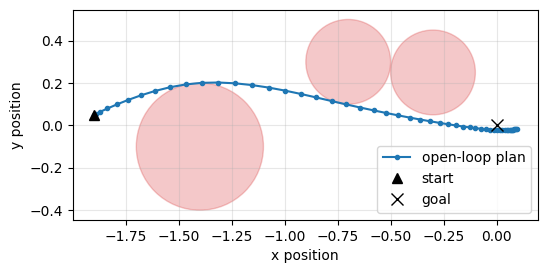

SQP iterations: 16 (max = 20)
ADMM iterations: [1690  645 3080  345  420 2895 1415  445   75   10   40   10    5    5
    5    5    0    0    0    0]
convergence_error: 9.976e-05 (max = 0.0001)


In [4]:
max_sqp_iter = 20
sqp_tol = 1e-4
cfg_open_loop = make_drone_config(
    use_slack=False,
    slack_weight=slack_weight,
    rd_weight=rd_weight,
    discretization_scheme=discretization_scheme,
    dt=dt,
    horizon=horizon,
    sqp_iter=max_sqp_iter,
    admm_tol=1e-5,
    admm_max_iter=5000,
    sqp_tol=sqp_tol
)

problem = cfg_open_loop.problem_class(
    dynamics=cfg_open_loop.dynamics,
    params=cfg_open_loop.problem_params,
)
solver = TurboMPCSolver(
    program=problem,
    params=cfg_open_loop.solver_params,
    forward_backend=fwd_backend,
    backward_backend=bwd_backend,
)

initial_guess = solver.initial_guess(cfg_open_loop.problem_params)
weights = {k: cfg_open_loop.problem_params[k] for k in cfg_open_loop.weight_keys}
solution = solver.solve(initial_guess, cfg_open_loop.problem_params, weights)

states = np.asarray(solution.states)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(states[:, 0], states[:, 1], "o-", ms=3, label="open-loop plan")
ax.plot(states[0, 0], states[0, 1], "k^", ms=7, label="start")
ax.plot(0.0, 0.0, "kx", ms=8, label="goal")
for center, radius in zip(OBS_CENTERS, OBS_RADII):
    ax.add_patch(Circle(center, radius, color="tab:red", alpha=0.25))
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

print(f"SQP iterations: {int(solution.num_iter)} (max = {int(max_sqp_iter)})")
print(f"ADMM iterations: {solution.admm_iters}")
print(f"convergence_error: {float(solution.convergence_error):.3e} (max = {sqp_tol})")


### Closed-Loop MPC: without slack variables

Each call to `collect_turbompc_drone_trajectory` runs a full closed-loop MPC simulation:
1. From the current state $x_t$, solve the OCP with `TurboMPCSolver` and apply the first control $u_0^*$.
2. Advance the true drone state one step with the same integrator.
3. Repeat for `sim_steps` steps.

Without slack variables the obstacle constraints are enforced as hard nonlinear inequalities.

In [5]:
cfg_noslack = make_drone_config(
    use_slack=False,
    rd_weight=rd_weight,
    discretization_scheme=discretization_scheme,
    dt=dt,
    horizon=horizon,
    sqp_iter=sqp_iter,
    admm_tol=admm_tol,
    admm_max_iter=admm_max_iter,
)

trajs_noslack, metrics_noslack = [], []
for seed in seeds:
    traj, metrics, _ = collect_turbompc_drone_trajectory(
        cfg_noslack,
        sim_steps=sim_steps,
        seed=seed,
        fwd_backend=fwd_backend,
        bwd_backend=bwd_backend,
        arc_init=arc_init,
        zeros_init=zeros_init,
    )
    trajs_noslack.append(traj)
    metrics_noslack.append(metrics)
    print(
        f"seed={seed}  violations={metrics['n_violations']:3d}"
        f"  max_viol={metrics['max_violation']:.4f}"
        f"  terminal_norm={metrics['terminal_state_norm']:.4f}"
    )

seed=0  violations=  3  max_viol=0.0105  terminal_norm=0.0267
seed=1  violations=  1  max_viol=0.0024  terminal_norm=0.0374


### Closed-Loop MPC: with slack variables

With slack variables the obstacle inequality $h_i(x_t) \ge 0$ is relaxed to $h_i(x_t) +\xi_t \ge 0$. This makes the problem always feasible at the cost of potentially allowing small constraint violations, which can be useful when initialising from challenging states.

In [6]:
cfg_slack = make_drone_config(
    use_slack=True,
    slack_weight=slack_weight,
    rd_weight=rd_weight,
    discretization_scheme=discretization_scheme,
    dt=dt,
    horizon=horizon,
    sqp_iter=sqp_iter,
    admm_tol=admm_tol,
    admm_max_iter=admm_max_iter,
)

trajs_slack, metrics_slack = [], []
for seed in seeds:
    traj, metrics, _ = collect_turbompc_drone_trajectory(
        cfg_slack,
        sim_steps=sim_steps,
        seed=seed,
        fwd_backend=fwd_backend,
        bwd_backend=bwd_backend,
        arc_init=arc_init,
        zeros_init=zeros_init,
    )
    trajs_slack.append(traj)
    metrics_slack.append(metrics)
    print(
        f"seed={seed}  violations={metrics['n_violations']:3d}"
        f"  max_viol={metrics['max_violation']:.4f}"
        f"  terminal_norm={metrics['terminal_state_norm']:.4f}"
    )

seed=0  violations=  6  max_viol=0.0965  terminal_norm=0.0182
seed=1  violations=  1  max_viol=0.0070  terminal_norm=0.0119


### Closed-loop Trajectory plot

The drone state is $x = (p_x, p_y, p_z, v_x, v_y, v_z)$; we plot the $x$-$y$ position. Blue solid lines = no-slack, orange dashed lines = slack. The star marks the goal $(0, 0)$, the triangle marks the starting position.

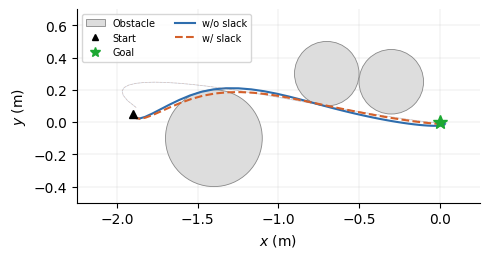

In [7]:
_C_NOSLACK = "#2E6DAD"
_C_SLACK    = "#D4602A"

fig, ax = plt.subplots(figsize=(5, 4))

# Obstacles
for (cx, cy), r in zip(OBS_CENTERS, OBS_RADII):
    ax.add_patch(Circle((cx, cy), r, fc="#DDDDDD", ec="#888888", lw=0.6, zorder=2))

# Start / goal markers
ax.plot(DRONE_X0_BASE[0], DRONE_X0_BASE[1], "k^", ms=6, zorder=8)
ax.plot(0.0, 0.0, "*", color="#1CA832", ms=10, zorder=8)

# Trajectories
for i, traj in enumerate(trajs_noslack):
    ax.plot(traj[:, 0], traj[:, 1],
            color=_C_NOSLACK, ls="-",
            lw=1.5 if i == 0 else 0.5,
            alpha=1.0 if i == 0 else 0.25,
            zorder=4)

for i, traj in enumerate(trajs_slack):
    ax.plot(traj[:, 0], traj[:, 1],
            color=_C_SLACK, ls="--",
            lw=1.5 if i == 0 else 0.5,
            alpha=1.0 if i == 0 else 0.25,
            zorder=4)

# Legend
handles = [
    mpatches.Patch(fc="#DDDDDD", ec="#888888", lw=0.6, label="Obstacle"),
    Line2D([0], [0], color="k",        marker="^", ls="none", ms=5,   label="Start"),
    Line2D([0], [0], color="#1CA832",  marker="*", ls="none", ms=7,   label="Goal"),
    Line2D([0], [0], color=_C_NOSLACK, lw=1.5,     ls="-",            label="w/o slack"),
    Line2D([0], [0], color=_C_SLACK,   lw=1.5,     ls="--",           label="w/ slack"),
]
ax.legend(handles=handles, fontsize=7, loc="upper left", ncol=2)

ax.set_xlim(-2.25, 0.25)
ax.set_ylim(-0.50, 0.70)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("$x$ (m)")
ax.set_ylabel("$y$ (m)")
ax.grid(True, lw=0.3, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### What you could try next

- **Control-rate weight `rd_weight`**: increasing it (e.g. `0.1`, `1.0`) should produce smoother but less aggressive trajectories. Lowering it allows sharper manoeuvres.
- **Slack penalty `slack_weight`**: Higher values should push the slack solution closer to the hard-constraint solution; lower values should tolerate more obstacle penetration in exchange for a smoother path.
- **Discretization scheme**: try `discretization_scheme = 0` (Euler) for faster integration or `discretization_scheme = 10` (implicit trapezoidal) for the most accurate. RK4 (`discretization_scheme = 2`) is the default.
- **Backends**: On a GPU machine swap to `fwd_backend = parse_forward_backend("admm_fused_cudss")` and `bwd_backend = parse_backward_backend("direct_cudss_ffi")` for a large speed-up.
- **Warm-start**: Set `init_mode = "arc"` to initialise the MPC with a trajectory that already arcs over the obstacles, which can help convergence from challenging starting positions.
- **Planning horizon**: A shorter horizon (`horizon = 20`) may cause the solver to be short-sighted near obstacles. Longer horizons improve constraint satisfaction at higher compute cost.